<a href="https://colab.research.google.com/github/Ushama253/northstar-analytics/blob/main/Section3_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

In [ ]:
base_path = "/content/northstar-analytics/north_dataset/"

orders     = pd.read_csv(base_path + "orders.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
customers  = pd.read_csv(base_path + "customers.csv")
drivers    = pd.read_csv(base_path + "drivers.csv")
vehicles   = pd.read_csv(base_path + "vehicles.csv")
incidents  = pd.read_csv(base_path + "incidents.csv")
hubs       = pd.read_csv(base_path + "hubs.csv")
app_events = pd.read_csv(base_path + "app_events.csv")

print("All files loaded successfully.")
print(f"Orders: {orders.shape}, Deliveries: {deliveries.shape}, App Events: {app_events.shape}")

All files loaded successfully.
Orders: (1250, 11), Deliveries: (950, 13), App Events: (640, 10)


**Cleaning the Data**

Before we move on to the analysis lets clean the dataset.
- Inconsistent zones
- Missing values
- Timestamps that need to be converted to datetime format


In [ ]:
# Fixing the zone

def clean_zone(value):
    if pd.isna(value):
        return value
    value = str(value).strip().lower()
    mapping = {
        "airport":   "Airport",
        "north":     "North",
        "south":     "South",
        "east":      "East",
        "west":      "West",
        "central":   "Central",
        "ctr":       "Central",
        "riverside": "Riverside"
    }
    return mapping.get(value, value.title())

orders["pickup_zone"]       = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"]      = orders["dropoff_zone"].apply(clean_zone)
drivers["base_zone"]        = drivers["base_zone"].apply(clean_zone)
customers["home_zone"]      = customers["home_zone"].apply(clean_zone)
vehicles["assigned_zone"]   = vehicles["assigned_zone"].apply(clean_zone)
app_events["zone_context"]  = app_events["zone_context"].apply(clean_zone)


In [ ]:
# Filling the missing values

deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median(), inplace=True)

complaints["compensation_amount"].fillna(
    complaints["compensation_amount"].median(), inplace=True)

customers["loyalty_score"].fillna(
    customers["loyalty_score"].median(), inplace=True)

drivers["training_score"].fillna(
    drivers["training_score"].median(), inplace=True)

vehicles["battery_health_pct"].fillna(
    vehicles["battery_health_pct"].median(), inplace=True)

incidents["resolved_hours"].fillna(
    incidents["resolved_hours"].median(), inplace=True)

orders["booking_channel"].fillna("Unknown", inplace=True)
customers["preferred_channel"].fillna("Unknown", inplace=True)

/tmp/ipykernel_12678/1368559855.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  deliveries["customer_rating_post_delivery"].fillna(
/tmp/ipykernel_12678/1368559855.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
# app_events: order_id might have missing values. Lets fill it with a string value that says "No Order"

app_events["order_id"].fillna("No Order", inplace=True)

In [ ]:
# Converting the Timestamps

deliveries["dispatch_time"]          = pd.to_datetime(deliveries["dispatch_time"],          errors="coerce")
deliveries["delivery_completed_at"]  = pd.to_datetime(deliveries["delivery_completed_at"],  errors="coerce")
orders["order_created_at"]           = pd.to_datetime(orders["order_created_at"],           errors="coerce")
app_events["event_timestamp"]        = pd.to_datetime(app_events["event_timestamp"],        errors="coerce")

print("\nData cleaning complete.")
print(f"Remaining missing values - Deliveries: {deliveries.isnull().sum().sum()}")
print(f"Remaining missing values - Complaints: {complaints.isnull().sum().sum()}")


Data cleaning complete.
Remaining missing values - Deliveries: 19
Remaining missing values - Complaints: 0


**Feature Engineering**

We create new columns that will help us identify patterns that are not directly visible in the raw data.

In [ ]:
# Delivering delay flag

deliveries["is_failed"]  = deliveries["delivery_status"] == "Failed"
deliveries["is_delayed"] = deliveries["delivery_status"] == "Delayed"
deliveries["is_ontime"]  = deliveries["delivery_status"] == "OnTime"

In [ ]:
# Actual delivering duration (hours) where both timestamps exist

deliveries["delivery_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

In [ ]:
# Flag deliveries where duration is negative (data error)

deliveries["timestamp_error"] = deliveries["delivery_duration_hrs"] < 0

In [ ]:
# Cost per km ratio

deliveries["cost_per_km"] = np.where(
    deliveries["route_distance_km"] > 0,
    deliveries["fuel_or_charge_cost"] / deliveries["route_distance_km"],
    np.nan
)

In [ ]:
# App event: flag high latency (above 800ms is considered slow)

app_events["high_latency"] = app_events["api_latency_ms"] > 800

In [ ]:
# Flag failed app events

app_events["event_failed"] = app_events["success_flag"] == 0

print("\nFeature engineering complete.")
print(f"Timestamp errors found: {deliveries['timestamp_error'].sum()}")
print(f"High latency events: {app_events['high_latency'].sum()} out of {len(app_events)}")


Feature engineering complete.
Timestamp errors found: 64
High latency events: 57 out of 640


**1st Analysis: Missing Values Heatmap**

Shows where data gaps exist across the dataset before and after cleaning demonstrating awareness of data quality.

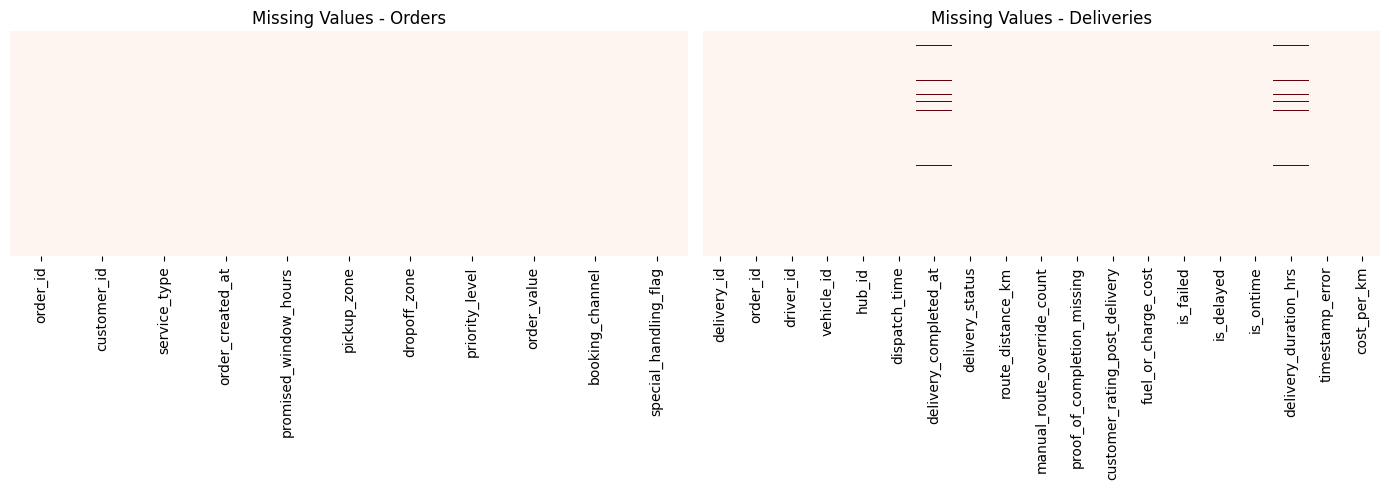

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(orders.isnull(), cbar=False, ax=axes[0], yticklabels=False, cmap="Reds")
axes[0].set_title("Missing Values - Orders")

sns.heatmap(deliveries.isnull(), cbar=False, ax=axes[1], yticklabels=False, cmap="Reds")
axes[1].set_title("Missing Values - Deliveries")

plt.tight_layout()
plt.show()

**2nd Analysis: Delivery Status Breakdown with Percentages**

A clear picture of the overall operational health, what proportion of deliveries are failing or delayed.

In [ ]:
status_counts = deliveries["delivery_status"].value_counts()
status_pct    = round(deliveries["delivery_status"].value_counts(normalize=True) * 100, 1)

print("\n Delivery Status \n")
print(pd.DataFrame({"Count": status_counts, "Percentage": status_pct}))


 Delivery Status 

                 Count  Percentage
delivery_status                   
OnTime             616        64.8
Delayed            202        21.3
Failed             132        13.9


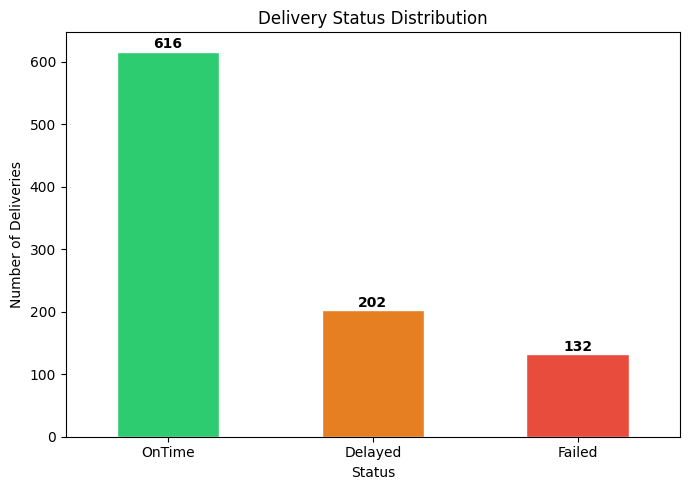

In [ ]:
colors = ["#2ecc71", "#e67e22", "#e74c3c"]
plt.figure(figsize=(7, 5))
status_counts.plot(kind="bar", color=colors, edgecolor="white")
plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)
for i, v in enumerate(status_counts):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**3rd Analysis: Failure Rate by Zone**

Merges orders and deliveries to find which city zones have the highest proportion of failed deliveries.

In [ ]:
zone_data = deliveries.merge(orders[["order_id", "pickup_zone"]], on="order_id", how="left")

zone_summary = zone_data.groupby("pickup_zone").agg(
    total        = ("delivery_id", "count"),
    failed       = ("is_failed", "sum"),
    delayed      = ("is_delayed", "sum")
).reset_index()

zone_summary["failure_rate_pct"] = round(
    (zone_summary["failed"] + zone_summary["delayed"]) / zone_summary["total"] * 100, 1)

zone_summary = zone_summary.sort_values("failure_rate_pct", ascending=False)

print("\n Failure Rate by Zone \n")
print(zone_summary)


 Failure Rate by Zone 

  pickup_zone  total  failed  delayed  failure_rate_pct
1     Central    174      33       51              48.3
0     Airport    113      12       31              38.1
4   Riverside    119      18       25              36.1
2        East    156      19       31              32.1
3       North    135      22       21              31.9
6        West    114      14       21              30.7
5       South    139      14       22              25.9


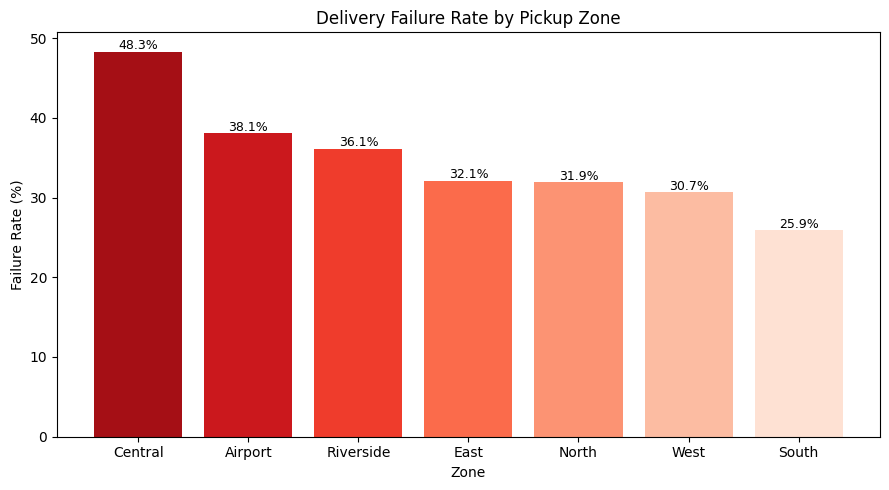

In [ ]:
plt.figure(figsize=(9, 5))
bars = plt.bar(zone_summary["pickup_zone"], zone_summary["failure_rate_pct"],
               color=sns.color_palette("Reds_r", len(zone_summary)))
plt.title("Delivery Failure Rate by Pickup Zone")
plt.xlabel("Zone")
plt.ylabel("Failure Rate (%)")
for bar, val in zip(bars, zone_summary["failure_rate_pct"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**4th Analysis: Revenue and Order Volume by Service Type**

Identifies which services generate the most revenue and volume for NorthStar.

In [ ]:
service_summary = orders.groupby("service_type").agg(
    total_orders  = ("order_id", "count"),
    total_revenue = ("order_value", "sum"),
    avg_value     = ("order_value", "mean")
).reset_index().sort_values("total_revenue", ascending=False)

service_summary["total_revenue"] = service_summary["total_revenue"].round(2)
service_summary["avg_value"]     = service_summary["avg_value"].round(2)

print("\n Revenue by Service Type \n")
print(service_summary)


 Revenue by Service Type 

  service_type  total_orders  total_revenue  avg_value
3    Passenger           341       32761.11      96.07
2       Parcel           308       26985.62      87.62
4       Retail           297       26734.06      90.01
0     Business           165       15220.43      92.25
1      Medical           139       12111.93      87.14


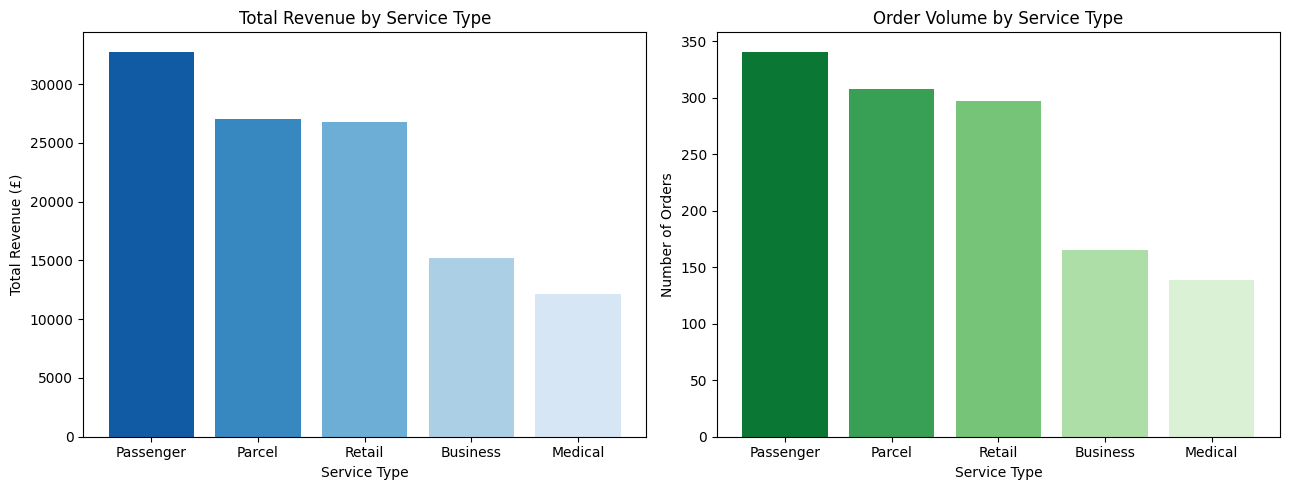

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(service_summary["service_type"], service_summary["total_revenue"],
            color=sns.color_palette("Blues_r", len(service_summary)))
axes[0].set_title("Total Revenue by Service Type")
axes[0].set_xlabel("Service Type")
axes[0].set_ylabel("Total Revenue (£)")

axes[1].bar(service_summary["service_type"], service_summary["total_orders"],
            color=sns.color_palette("Greens_r", len(service_summary)))
axes[1].set_title("Order Volume by Service Type")
axes[1].set_xlabel("Service Type")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**5th Analysis: Cost Per KM by Vehicle Type**

Compares how efficiently different vehicle types convert distance into cost, EVs should be cheaper per km.

In [ ]:
cost_data = deliveries.merge(vehicles[["vehicle_id", "vehicle_type"]], on="vehicle_id", how="left")
cost_data = cost_data.dropna(subset=["cost_per_km", "vehicle_type"])

print("\n Cost Per KM by Vehicle Type \n")
print(cost_data.groupby("vehicle_type")["cost_per_km"].describe().round(3))


 Cost Per KM by Vehicle Type 

              count   mean    std    min    25%    50%    75%     max
vehicle_type                                                         
CargoVan      223.0  1.231  1.027  0.196  0.696  0.998  1.336   8.500
Diesel        144.0  1.447  1.515  0.286  0.757  1.064  1.476  10.208
EV            339.0  1.205  1.188  0.255  0.685  0.899  1.299  11.545
Hybrid        244.0  1.259  1.302  0.174  0.735  0.962  1.245  12.364


/tmp/ipykernel_12678/3335707515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cost_data, x="vehicle_type", y="cost_per_km",


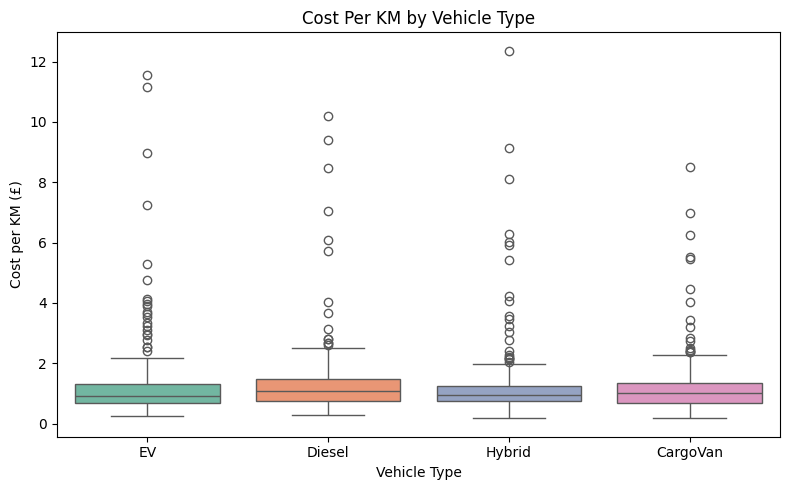

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=cost_data, x="vehicle_type", y="cost_per_km",
            palette="Set2")
plt.title("Cost Per KM by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Cost per KM (£)")
plt.tight_layout()
plt.show()

**6th Analysis: App Event Analysis - Latency and Failures**

High API latency causes failed app interactions which leads to customer frustration and complaints.

In [ ]:
event_summary = app_events.groupby("event_type").agg(
    total_events   = ("event_id", "count"),
    failed_events  = ("event_failed", "sum"),
    avg_latency_ms = ("api_latency_ms", "mean"),
    high_latency   = ("high_latency", "sum")
).reset_index()

In [ ]:
event_summary["fail_rate_pct"]  = round(event_summary["failed_events"] / event_summary["total_events"] * 100, 1)
event_summary["avg_latency_ms"] = event_summary["avg_latency_ms"].round(1)
event_summary = event_summary.sort_values("fail_rate_pct", ascending=False)

print("\n App Event Summary \n")
print(event_summary)


 App Event Summary 

                    event_type  total_events  failed_events  avg_latency_ms  \
1               chat_escalated            38             19           478.1   
5                payment_retry            69             19           472.7   
2                  chat_opened            88              0           478.3   
0               cancel_attempt            28              0           417.1   
3  delivery_instruction_update            75              0           496.3   
4                  eta_refresh           105              0           452.2   
6                 search_route            99              0           456.5   
7                  track_order           138              0           460.7   

   high_latency  fail_rate_pct  
1             5           50.0  
5             6           27.5  
2             9            0.0  
0             2            0.0  
3            11            0.0  
4             6            0.0  
6             5            0.0  
7 

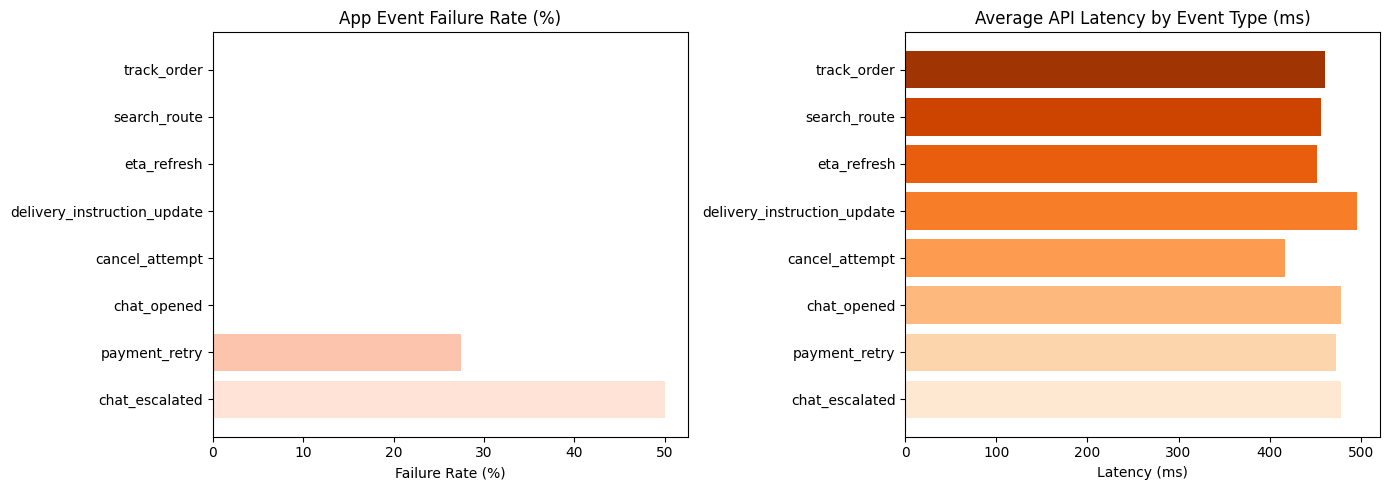

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(event_summary["event_type"], event_summary["fail_rate_pct"],
             color=sns.color_palette("Reds", len(event_summary)))
axes[0].set_title("App Event Failure Rate (%)")
axes[0].set_xlabel("Failure Rate (%)")

axes[1].barh(event_summary["event_type"], event_summary["avg_latency_ms"],
             color=sns.color_palette("Oranges", len(event_summary)))
axes[1].set_title("Average API Latency by Event Type (ms)")
axes[1].set_xlabel("Latency (ms)")

plt.tight_layout()
plt.show()

**7th Analysis: Complaint Heatmap by Type and Severity**

A heatmap shows which combinations of complaint type and severity are most common - useful for prioritisation.

In [ ]:
complaint_pivot = complaints.groupby(["complaint_type", "severity"]).size().unstack(fill_value=0)

print("\n Complaint Heatmap Data \n")
print(complaint_pivot)


 Complaint Heatmap Data 

severity           High  Low  Medium
complaint_type                      
AppIssue             13   15      25
Billing               4    3       9
Damage                7    6       2
Delay                18   27      56
DriverBehaviour      16    4      31
MissedPickup         16   11      37
SupportExperience     3    5      12


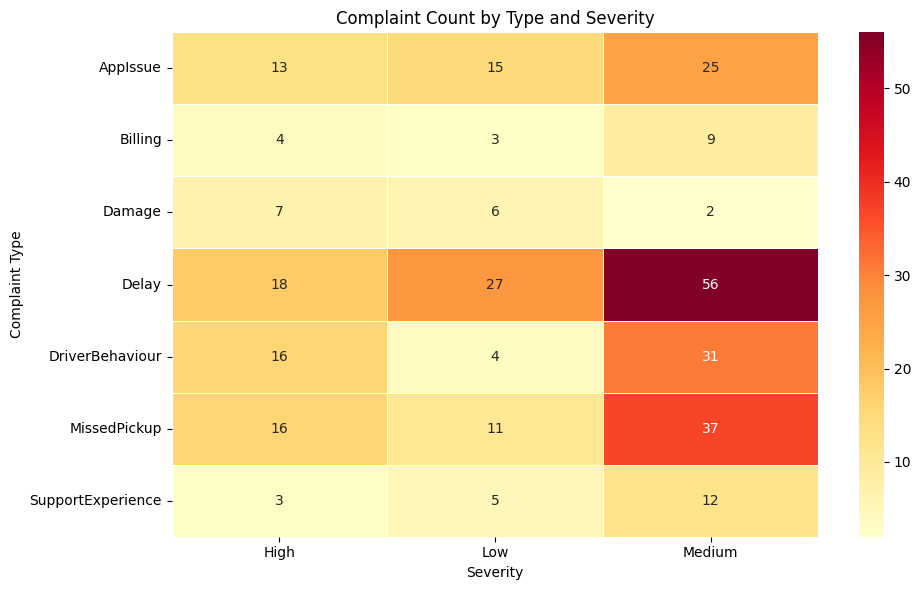

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(complaint_pivot, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5)
plt.title("Complaint Count by Type and Severity")
plt.xlabel("Severity")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

**8th Analysis: Manual Route Overrides by Hub**

High override counts at certain hubs suggest route planning is failing in those areas, or drivers are avoiding performance targets.

In [ ]:
override_summary = deliveries.groupby("hub_id").agg(
    total_deliveries = ("delivery_id", "count"),
    total_overrides  = ("manual_route_override_count", "sum"),
    avg_overrides    = ("manual_route_override_count", "mean")
).reset_index().sort_values("total_overrides", ascending=False)

override_summary["avg_overrides"] = override_summary["avg_overrides"].round(2)

print("\n Manual Route Overrides by Hub \n")
print(override_summary)


 Manual Route Overrides by Hub 

  hub_id  total_deliveries  total_overrides  avg_overrides
7    H08               128              142           1.11
0    H01               136              140           1.03
6    H07               115              121           1.05
3    H04               127              111           0.87
4    H05               115              109           0.95
2    H03               119              106           0.89
1    H02               106               97           0.92
5    H06               104               95           0.91


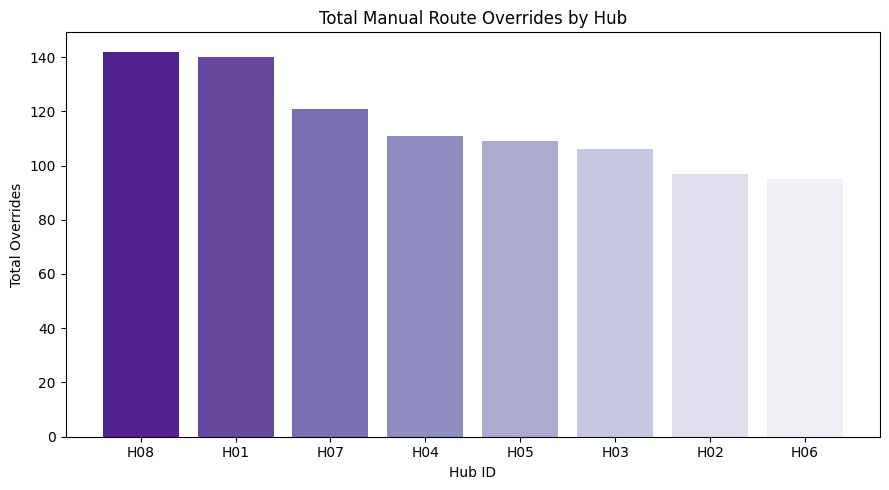

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(override_summary["hub_id"], override_summary["total_overrides"],
        color=sns.color_palette("Purples_r", len(override_summary)))
plt.title("Total Manual Route Overrides by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Total Overrides")
plt.tight_layout()
plt.show()

**9th Analysis: NumPy Statistical Summary**

Using NumPy directly to compute key statistics for the report, demonstrates use of NumPy as required.

In [ ]:
print("\n NumPy Statistical Summary \n")

order_values = orders["order_value"].dropna().values
print(f"\nOrder Values:")
print(f"  Mean:     £{np.mean(order_values):.2f}")
print(f"  Median:   £{np.median(order_values):.2f}")
print(f"  Std Dev:  £{np.std(order_values):.2f}")
print(f"  Min:      £{np.min(order_values):.2f}")
print(f"  Max:      £{np.max(order_values):.2f}")

latency = app_events["api_latency_ms"].values
print(f"\nApp Latency (ms):")
print(f"  Mean:     {np.mean(latency):.1f}ms")
print(f"  Median:   {np.median(latency):.1f}ms")
print(f"  95th pct: {np.percentile(latency, 95):.1f}ms")
print(f"  Max:      {np.max(latency):.1f}ms")

ratings = deliveries["customer_rating_post_delivery"].dropna().values
print(f"\nCustomer Ratings:")
print(f"  Mean:     {np.mean(ratings):.2f}")
print(f"  Std Dev:  {np.std(ratings):.2f}")
print(f"  % below 3: {round(np.mean(ratings < 3) * 100, 1)}%")


 NumPy Statistical Summary 


Order Values:
  Mean:     £91.05
  Median:   £76.53
  Std Dev:  £60.89
  Min:      £2.04
  Max:      £510.06

App Latency (ms):
  Mean:     465.7ms
  Median:   432.5ms
  95th pct: 897.2ms
  Max:      1701.0ms

Customer Ratings:
  Mean:     3.87
  Std Dev:  0.89
  % below 3: 16.4%


**10th Analysis: Correlation Matrix**

A heatmap of numeric correlations across the deliveries table reveals which variables move together.

In [ ]:
numeric_cols = deliveries[[
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "cost_per_km",
    "delivery_duration_hrs"
]].dropna()

In [ ]:
corr_matrix = numeric_cols.corr().round(2)

print("\n Correlation Matrix \n")
print(corr_matrix)


 Correlation Matrix 

                               route_distance_km  manual_route_override_count  \
route_distance_km                           1.00                         0.21   
manual_route_override_count                 0.21                         1.00   
customer_rating_post_delivery               0.03                        -0.06   
fuel_or_charge_cost                         0.52                         0.10   
cost_per_km                                -0.51                        -0.04   
delivery_duration_hrs                       0.02                        -0.01   

                               customer_rating_post_delivery  \
route_distance_km                                       0.03   
manual_route_override_count                            -0.06   
customer_rating_post_delivery                           1.00   
fuel_or_charge_cost                                    -0.06   
cost_per_km                                            -0.09   
delivery_duration_hrs    

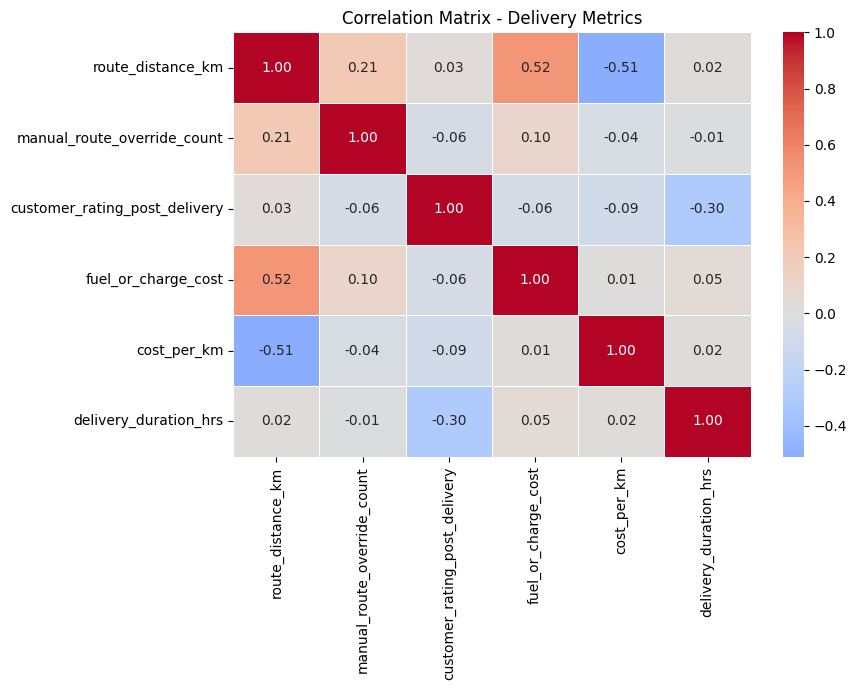

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm",
            center=0, linewidths=0.5, fmt=".2f")
plt.title("Correlation Matrix - Delivery Metrics")
plt.tight_layout()
plt.show()